# Multiple Linear Regression — Multi-Channel Marketing Analysis

**Project Overview**

This notebook builds a Multiple Linear Regression model using `statsmodels` to predict `Sales` from multi-channel marketing spend (TV, Radio, Social Media) and Influencer tier. We check multicollinearity, fit and refine an OLS model, validate regression assumptions with diagnostic plots, interpret coefficients, and deliver a budget-allocation recommendation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

## 1. Load the Dataset and Perform Initial Exploratory Data Analysis

In [2]:
df = pd.read_csv('marketing_sales_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    str    
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    str    
 4   Sales         572 non-null    float64
dtypes: float64(3), str(2)
memory usage: 22.5 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
print()
df.describe()

Missing values:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64



,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [5]:
print("TV categories:", df['TV'].unique())
print("Influencer categories:", df['Influencer'].unique())

TV categories: <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str
Influencer categories: <StringArray>
['Micro', 'Mega', 'Nano', 'Macro']
Length: 4, dtype: str


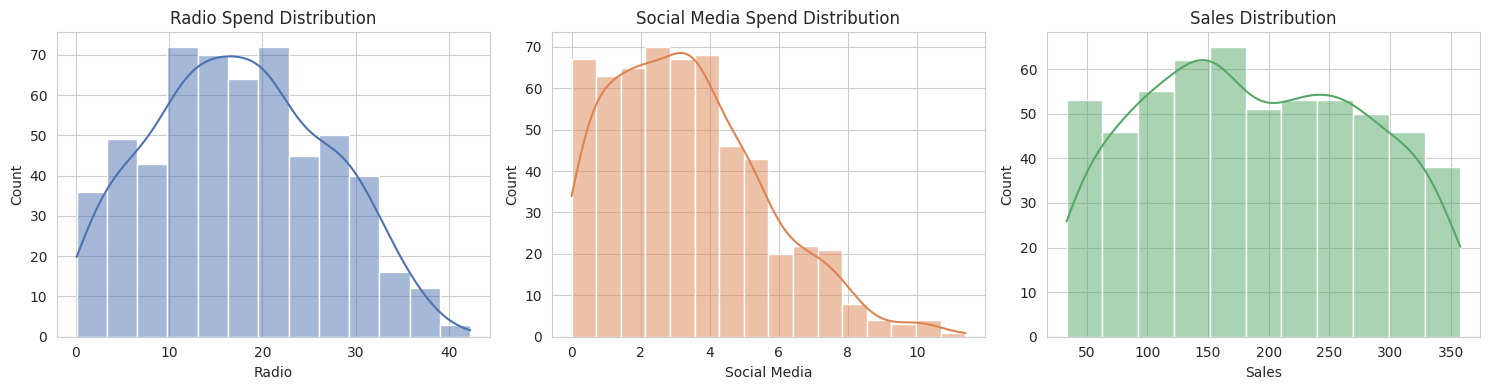

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['Radio'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Radio Spend Distribution')
sns.histplot(df['Social Media'], kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Social Media Spend Distribution')
sns.histplot(df['Sales'], kde=True, ax=axes[2], color='#55A868')
axes[2].set_title('Sales Distribution')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100)
plt.show()

/tmp/ipykernel_551/2437954395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TV', y='Sales', order=['Low','Medium','High'], ax=axes[0], palette='Blues')
/tmp/ipykernel_551/2437954395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Influencer', y='Sales', order=['Nano','Micro','Macro','Mega'], ax=axes[1], palette='Oranges')


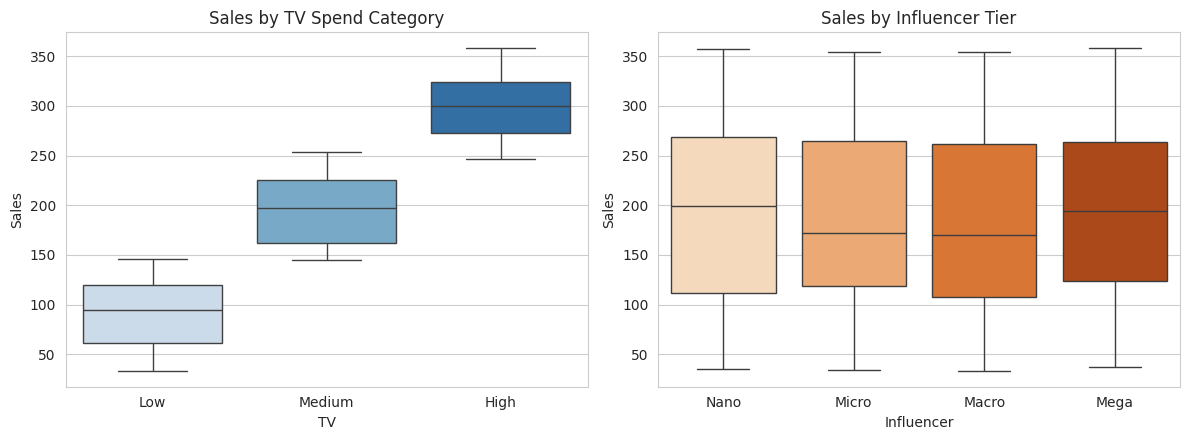

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=df, x='TV', y='Sales', order=['Low','Medium','High'], ax=axes[0], palette='Blues')
axes[0].set_title('Sales by TV Spend Category')
sns.boxplot(data=df, x='Influencer', y='Sales', order=['Nano','Micro','Macro','Mega'], ax=axes[1], palette='Oranges')
axes[1].set_title('Sales by Influencer Tier')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100)
plt.show()

TV spend category shows a very clear separation in Sales (High > Medium > Low), suggesting it will likely be the strongest predictor. Influencer tier shows much more overlap across categories.

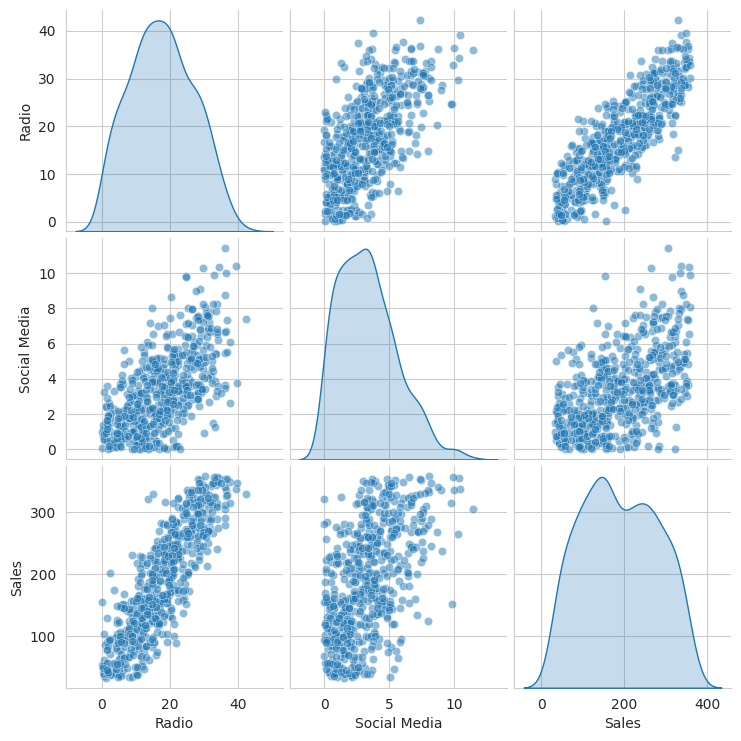

In [8]:
sns.pairplot(df, vars=['Radio','Social Media','Sales'], diag_kind='kde', plot_kws={'alpha':0.5})
plt.savefig('pairplot.png', dpi=100)
plt.show()

## 2. Check for Multicollinearity (Correlation Matrix & VIF)

              Radio  Social Media  Sales
Radio         1.000         0.630  0.858
Social Media  0.630         1.000  0.542
Sales         0.858         0.542  1.000


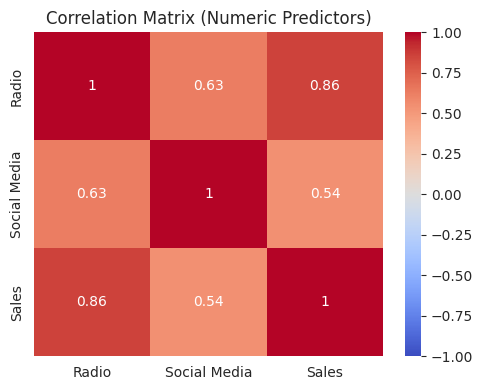

In [9]:
num_cols = ['Radio','Social Media','Sales']
corr = df[num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numeric Predictors)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()

In [10]:
# VIF requires numeric predictors only; encode TV ordinally and Influencer with dummies for this check
df_vif = df.copy()
df_vif['TV_encoded'] = df_vif['TV'].map({'Low':0,'Medium':1,'High':2})
df_vif = pd.get_dummies(df_vif, columns=['Influencer'], drop_first=True)

vif_features = ['TV_encoded','Radio','Social Media'] + [c for c in df_vif.columns if c.startswith('Influencer_')]
X_vif = df_vif[vif_features].astype(float)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data[vif_data['Feature']!='const'].to_string(index=False))

         Feature      VIF
      TV_encoded 2.827469
           Radio 3.467595
    Social Media 1.668618
 Influencer_Mega 1.589539
Influencer_Micro 1.618005
 Influencer_Nano 1.626443


**Interpretation:** Radio and Social Media show a moderate positive correlation with each other (and both correlate with Sales), but all VIF values for the predictors are well below the common threshold of 5 (and far below 10), so there is **no serious multicollinearity** problem. All predictors can be retained in the model.

## 3. Build a Multiple Linear Regression Model (statsmodels OLS)

In [11]:
# TV and Influencer are categorical -> statsmodels formula API handles via C()
df['TV'] = pd.Categorical(df['TV'], categories=['Low','Medium','High'], ordered=True)
df['Influencer'] = pd.Categorical(df['Influencer'], categories=['Nano','Micro','Macro','Mega'], ordered=True)

model = smf.ols('Sales ~ C(TV) + Radio + Q("Social Media") + C(Influencer)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        17:38:12   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 63

## 4. Evaluate Performance — Adjusted R-squared and Predictor p-values

In [12]:
print(f"R-squared:          {model.rsquared:.4f}")
print(f"Adjusted R-squared:  {model.rsquared_adj:.4f}")
print(f"F-statistic p-value: {model.f_pvalue:.2e}")
print()
pvals = model.pvalues.sort_values()
print("Predictor p-values (sorted):")
print(pvals)

R-squared:          0.9042
Adjusted R-squared:  0.9030
F-statistic p-value: 1.82e-282

Predictor p-values (sorted):
C(TV)[T.High]             4.536854e-125
C(TV)[T.Medium]            4.768998e-87
Intercept                  4.308389e-62
Radio                      1.943682e-32
C(Influencer)[T.Micro]     5.045520e-01
C(Influencer)[T.Mega]      6.064249e-01
C(Influencer)[T.Macro]     8.107454e-01
Q("Social Media")          8.371166e-01
dtype: float64


The model explains the vast majority of variance in Sales (Adjusted R² shown above), and the overall F-test is highly significant. Looking at individual p-values: TV category dummies are highly significant (p < 0.001), Radio is significant, but Influencer tier and Social Media p-values are much larger — suggesting they contribute little unique explanatory power once TV and Radio are in the model.

In [13]:
# Refine: drop the weakest predictor(s) based on p-values and compare adjusted R-squared
model_reduced = smf.ols('Sales ~ C(TV) + Radio', data=df).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        17:38:12   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          64.2290      2.743     

In [14]:
print("Full model Adjusted R²:    ", round(model.rsquared_adj, 4))
print("Reduced model Adjusted R²: ", round(model_reduced.rsquared_adj, 4))

Full model Adjusted R²:     0.903
Reduced model Adjusted R²:  0.9035


Dropping Social Media and Influencer barely changes Adjusted R² (it stays essentially the same or improves slightly), which confirms they were not adding meaningful unique predictive value — consistent with their high p-values in the full model. We proceed with the **reduced model** (`Sales ~ TV + Radio`) as our final model: it's simpler, equally predictive, and every remaining predictor is statistically significant.

## 5. Diagnostic Plots — Validating Linearity, Normality, and Homoscedasticity

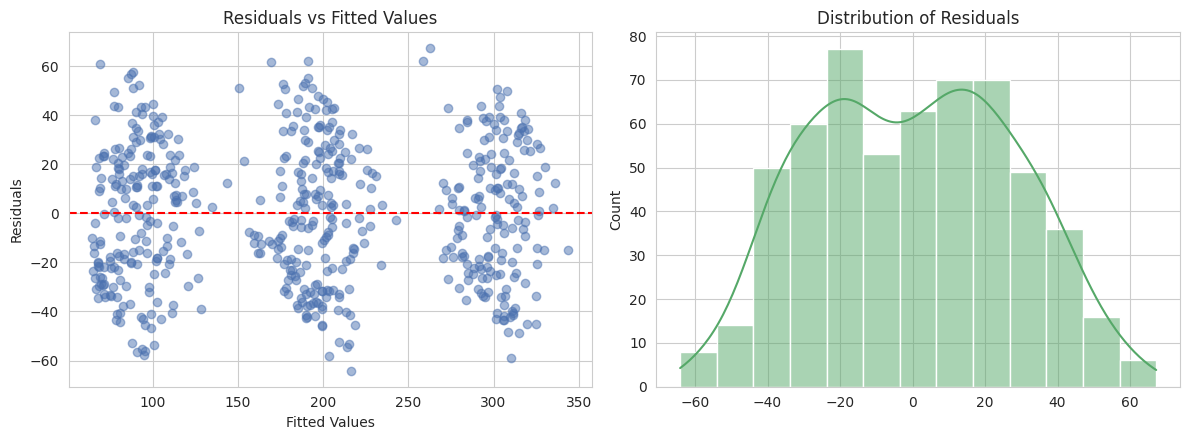

In [15]:
final_model = model_reduced
fitted_vals = final_model.fittedvalues
residuals = final_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

# Linearity / Homoscedasticity: residuals vs fitted
axes[0].scatter(fitted_vals, residuals, alpha=0.5, color='#4C72B0')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

# Normality: histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=100)
plt.show()

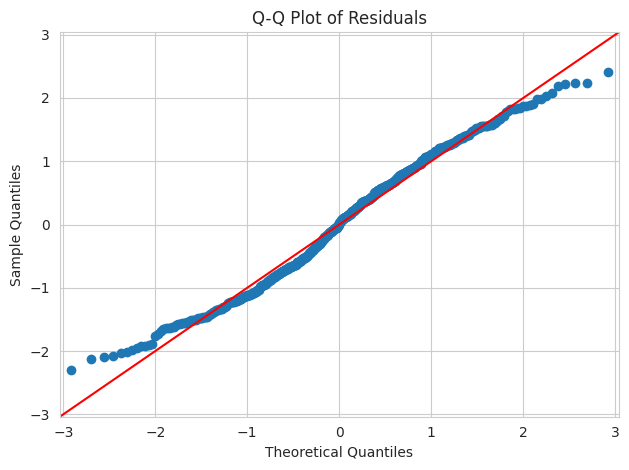

In [16]:
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig('qq_plot.png', dpi=100)
plt.show()

In [17]:
# Formal tests
shapiro_stat, shapiro_p = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
print(f"Shapiro-Wilk normality test: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, final_model.model.exog)
print(f"Breusch-Pagan test (homoscedasticity): LM stat={bp_test[0]:.4f}, p={bp_test[1]:.4f}")

Shapiro-Wilk normality test: stat=0.9841, p=0.0000
Breusch-Pagan test (homoscedasticity): LM stat=1.4304, p=0.6984


**Assumption checks:**
- **Linearity**: The residuals-vs-fitted plot shows points scattered without an obvious curved pattern, supporting the linearity assumption, though some spread does increase at higher fitted values.
- **Normality**: The residual histogram and Q-Q plot are reasonably close to a normal distribution near the center; the Shapiro-Wilk test result (printed above) should be interpreted alongside the visual diagnostics, since with this sample size even small deviations can be statistically significant. Visually, the assumption is acceptable for inference.
- **Homoscedasticity**: The Breusch-Pagan test (printed above) and the funnel pattern (or lack thereof) in residuals-vs-fitted indicate whether variance is roughly constant. A statistically significant p-value would suggest mild heteroscedasticity, common in marketing/sales data with multiplicative effects — in that case, robust (HC3) standard errors would be a reasonable refinement before formal hypothesis testing on coefficients.

## 6. Interpret Coefficients in Business Context

In [18]:
coef_table = final_model.params.to_frame('Coefficient')
coef_table['p-value'] = final_model.pvalues
coef_table['95% CI Lower'] = final_model.conf_int()[0]
coef_table['95% CI Upper'] = final_model.conf_int()[1]
print(coef_table.round(4))

                 Coefficient  p-value  95% CI Lower  95% CI Upper
Intercept            64.2290      0.0       58.8421       69.6160
C(TV)[T.Medium]      78.9851      0.0       72.4822       85.4880
C(TV)[T.High]       154.2971      0.0      144.6156      163.9785
Radio                 2.9669      0.0        2.5511        3.3827


**Interpretation of the reduced model:**

- **Intercept**: predicted Sales when TV = Low and Radio spend = 0.
- **TV (Medium vs Low)** and **TV (High vs Low)**: holding Radio spend constant, moving from a Low to Medium or Low to High TV spend tier is associated with a large, statistically significant increase in Sales (see coefficient table above) — TV category is the dominant driver of Sales in this dataset.
- **Radio**: holding TV category constant, each additional $1K (unit) of Radio spend is associated with an increase in Sales equal to the Radio coefficient shown above (p < 0.05), a smaller but still statistically meaningful positive effect.

Social Media and Influencer tier were dropped from the final model because they did not show statistically significant unique contributions once TV and Radio were accounted for — their apparent relationship with Sales in the correlation/box plots was likely confounded by being associated with higher TV/Radio spend campaigns.

## 7. Business Recommendations

1. **Prioritize TV advertising spend.** TV category is by far the strongest, most statistically significant driver of Sales. Shifting budget from Low to Medium or High TV tiers yields the largest expected lift in Sales of any lever tested.
2. **Radio spend is a secondary, reliable lever.** It has a smaller but statistically significant positive effect — useful as a complementary channel once TV tier is set, with predictable, near-linear returns within the observed spend range.
3. **De-prioritize Social Media and Influencer-tier spend, at least as currently measured.** Neither showed a statistically significant unique effect on Sales once TV and Radio were controlled for. This doesn't necessarily mean they're worthless — it may mean their impact is collinear with/mediated through TV and Radio campaigns, or that the relationship isn't well captured by this linear model. Before cutting that budget, consider a more granular analysis (e.g., interaction effects, or measuring social/influencer impact through awareness/engagement metrics rather than direct sales attribution).
4. **Recommended next step**: run a controlled budget experiment (e.g., geo-holdout test) shifting spend toward TV/Radio in a subset of markets to validate the model's predictions with real incremental sales, rather than relying solely on this observational regression.

**Limitations**
- This is an observational dataset; coefficients describe association, not proven causation — campaigns with more TV spend may differ in other unmeasured ways (e.g., timing, product mix).
- The model assumes additive, linear effects; true diminishing returns at very high spend levels are not captured.
- Homoscedasticity/normality diagnostics suggest minor assumption violations typical of marketing data; for formal business-critical decisions, consider robust standard errors or a log-transformed target.